In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

3,965 books scraped from Goodreads, focused on the Indian reading market. It covers books across English and several Indian + Middle Eastern languages, spanning publications from the 1800s through 2024, with a heavy concentration in the 2000s–2010s.

In [2]:
df_raw = pd.read_csv('goodreads_final.csv')

In [3]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9})

## Data Health

In [4]:
df_raw.head(4)

,title,author,genre,pages,rating,ratings_count,reviews_count,year,publisher,language,description,price
0,The Hunger Games,Suzanne Collins,"Young Adult, Dystopia, Fiction",374.0,4.35,10077406,268647,2008.0,Scholastic India,NaN,Winning means fame and fortune. Losing means c...,450.0
1,Catching Jordan,Miranda Kenneally,"Young Adult, Romance, Contemporary",288.0,3.83,64721,3872,2011.0,Scholastic,NaN,ONE OF THE BOYSWhat girl doesn't want to be su...,450.0
2,The Boy Who Sneaks in My Bedroom Window,Kirsty Moseley,"Romance, Young Adult, Contemporary",256.0,3.84,78310,5995,2012.0,Scholastic,NaN,"Liam James, boy next door and total douchebag,...",450.0
3,The Vincent Boys,Abbi Glines,"Romance, Young Adult, New Adult",260.0,3.94,75284,3999,2011.0,Simon & Schuster,NaN,"Ashton is getting tired of being good, of impr...",499.0


In [5]:
print("Shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns.tolist())
print("\nData Types:\n", df_raw.dtypes)

Shape: (3919, 12)

Columns:
 ['title', 'author', 'genre', 'pages', 'rating', 'ratings_count', 'reviews_count', 'year', 'publisher', 'language', 'description', 'price']

Data Types:
 title             object
author            object
genre             object
pages            float64
rating           float64
ratings_count      int64
reviews_count      int64
year             float64
publisher         object
language          object
description       object
price            float64
dtype: object


In [6]:
print(df_raw.isna().sum())

title               0
author              0
genre             325
pages             132
rating              0
ratings_count       0
reviews_count       0
year               56
publisher         678
language         1274
description        75
price             841
dtype: int64


In [7]:
df_raw.describe(include='all')

,title,author,genre,pages,rating,ratings_count,reviews_count,year,publisher,language,description,price
count,3919,3919,3594,3787.000000,3919.000000,3.919000e+03,3919.000000,3863.000000,3241,2645,3844,3078.000000
unique,3890,2575,1634,NaN,NaN,NaN,NaN,NaN,643,22,3832,NaN
top,Warrior,Naguib Mahfouz,"Romance, Contemporary Romance, Contemporary",NaN,NaN,NaN,NaN,NaN,HarperCollins,en,Reading books is a kind of enjoyment. Reading ...,NaN
freq,3,26,77,NaN,NaN,NaN,NaN,NaN,615,2039,4,NaN
mean,NaN,NaN,NaN,304.313705,3.937267,1.003994e+05,4897.167900,1999.127880,NaN,NaN,NaN,431.345214
std,NaN,NaN,NaN,164.206306,0.345546,4.843883e+05,18003.383358,27.611958,NaN,NaN,NaN,267.289442
min,NaN,NaN,NaN,6.000000,2.000000,1.000000e+00,0.000000,1811.000000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,200.000000,3.730000,3.795000e+02,53.000000,1996.000000,NaN,NaN,NaN,299.000000
50%,NaN,NaN,NaN,294.000000,3.940000,2.752000e+03,299.000000,2010.000000,NaN,NaN,NaN,399.000000
75%,NaN,NaN,NaN,378.000000,4.160000,2.059600e+04,1815.000000,2014.000000,NaN,NaN,NaN,450.000000


- Ratings count exhibits extremely high variability, with a large difference between median and maximum values, indicating a highly skewed distribution
- Review count also demonstrates strong right-skewness,showing only some books generates discussion among readers
- Ratings are concentrated within a relatively narrow range, indicating that most books receive moderately positive reader feedback

In [8]:
df = df_raw.copy()

In [9]:
# fixing datatypes
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['pages'] = pd.to_numeric(df['pages'], errors='coerce').astype('Int64')

In [10]:
# strip whitespace from text cols
for col in ['title', 'author', 'genre', 'description','language','publisher']:
    df[col] = df[col].str.strip()

In [11]:
#duplicate check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Univarite Analysis

### Categorical data

#### Authors

In [12]:
# top 10 authors with most books
top_authors = df['author'].value_counts().head(10)
total_authors = df['author'].nunique()
print(f"Total unique authors: {total_authors}")
print("Top 10 authors with most books:")
print(top_authors)

Total unique authors: 2575
Top 10 authors with most books:
author
Naguib Mahfouz         26
Ahmed Khaled Towfik    25
Agatha Christie        19
Hamilton Crane         17
S.L. Bhyrappa          17
Meg Cabot              16
عبدالرحمن منيف         15
Mostafa Mahmoud        14
Mahmoud Darwish        14
Tawfiq Al-Hakim        13
Name: count, dtype: int64


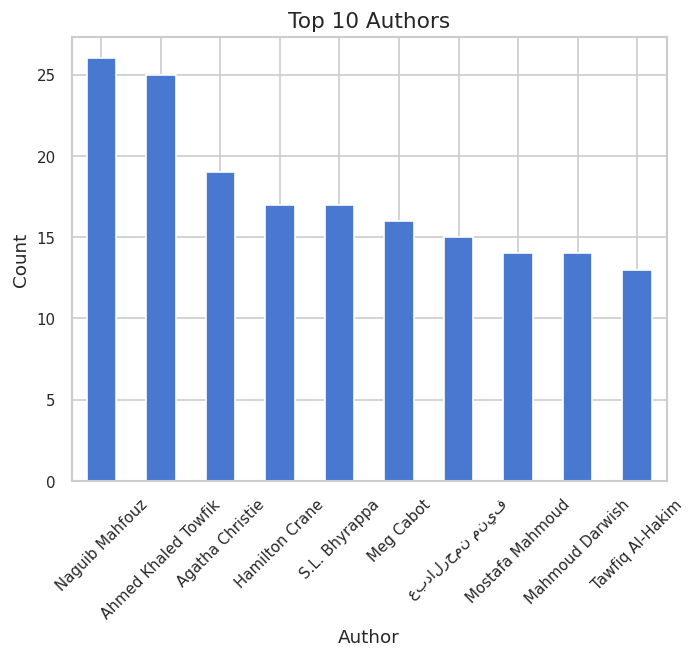

In [13]:
plt.figure()
top_authors.plot(kind='bar')
plt.title("Top 10 Authors")
plt.xlabel("Author")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

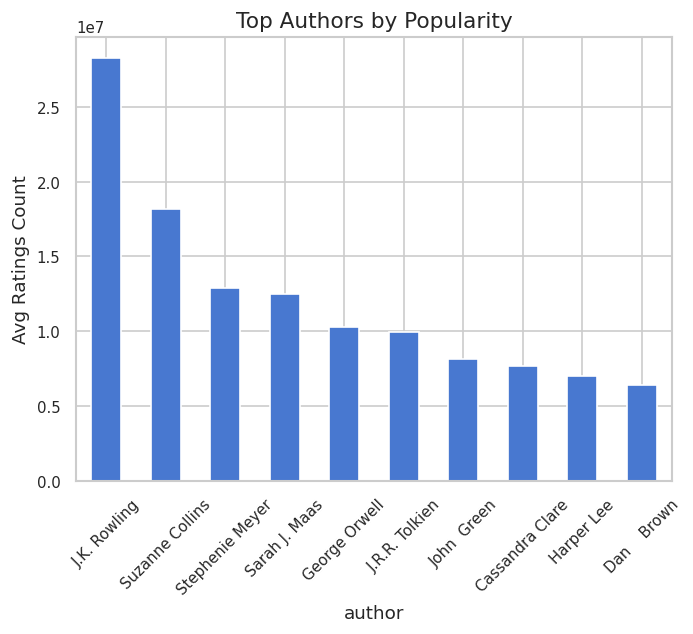

In [14]:
# author popularity
author_pop = df.groupby('author')['ratings_count'].sum().sort_values(ascending=False).head(10)

plt.figure()
author_pop.plot(kind='bar')
plt.title("Top Authors by Popularity")
plt.ylabel("Avg Ratings Count")
plt.xticks(rotation=45)
plt.show()

#### Genre

In [15]:
# top 10 genres
top_genres = df['genre'].value_counts().head(10)
print(f"Top 10 genres: {top_genres}")

Top 10 genres: genre
Romance, Contemporary Romance, Contemporary    77
Young Adult, Romance, Contemporary             65
Fantasy, Young Adult, Romance                  64
Novels, Fiction, Literature                    46
Romance, New Adult, Contemporary               41
Romance, Contemporary, Contemporary Romance    40
Romance, Young Adult, Contemporary             39
Fantasy, Young Adult, Fiction                  38
Young Adult, Paranormal, Fantasy               28
Young Adult, Fantasy, Paranormal               27
Name: count, dtype: int64


In [16]:
total_genres = df['genre'].nunique()
print(f"Total unique genres: {total_genres}")

Total unique genres: 1634


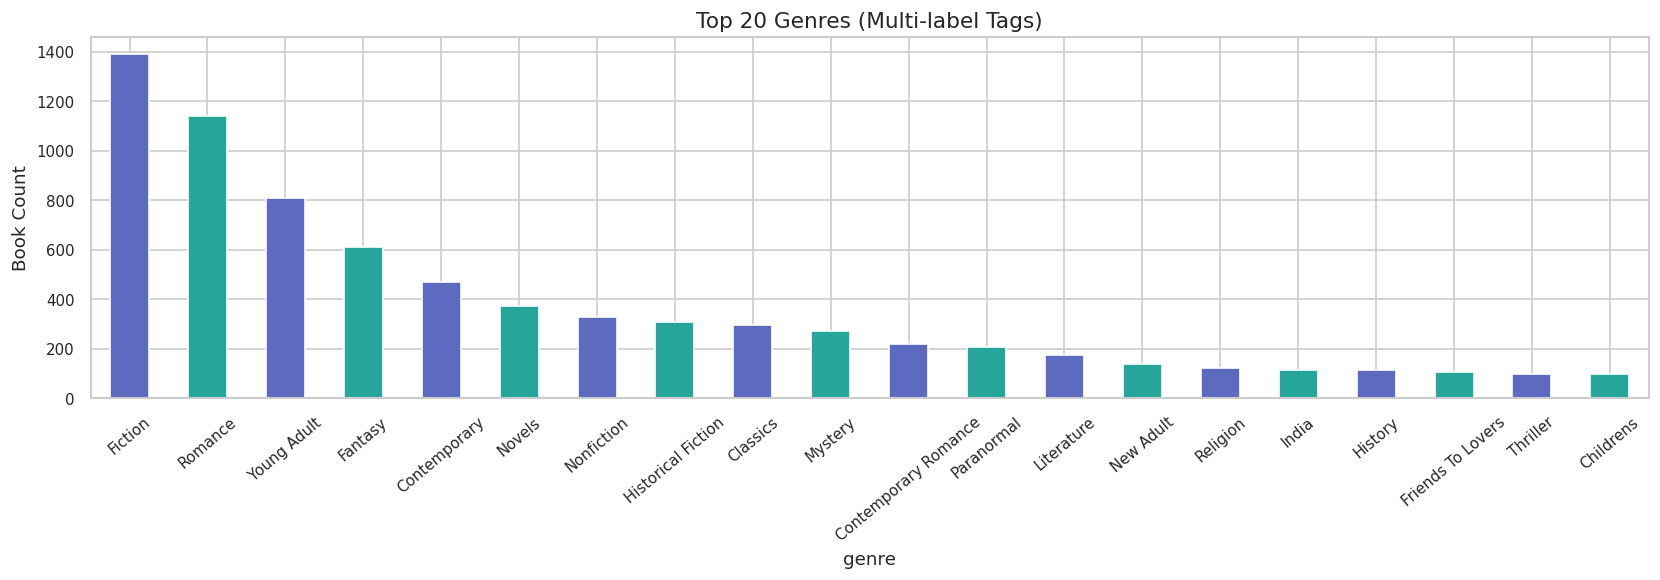

Unique genre tags  : 295
Avg tags per book  : 2.84


In [17]:
genres_exploded = df['genre'].dropna().str.split(',').explode().str.strip()
top12_genre_counts = genres_exploded.value_counts().head(12)

top20_genres = genres_exploded.value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#5C6BC0' if i%2==0 else '#26A69A' for i in range(len(top20_genres))]
top20_genres.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Genres (Multi-label Tags)')
ax.set_ylabel('Book Count'); ax.tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()

print(f"Unique genre tags  : {genres_exploded.nunique()}")
print(f"Avg tags per book  : {df['genre'].dropna().str.split(',').apply(len).mean():.2f}")

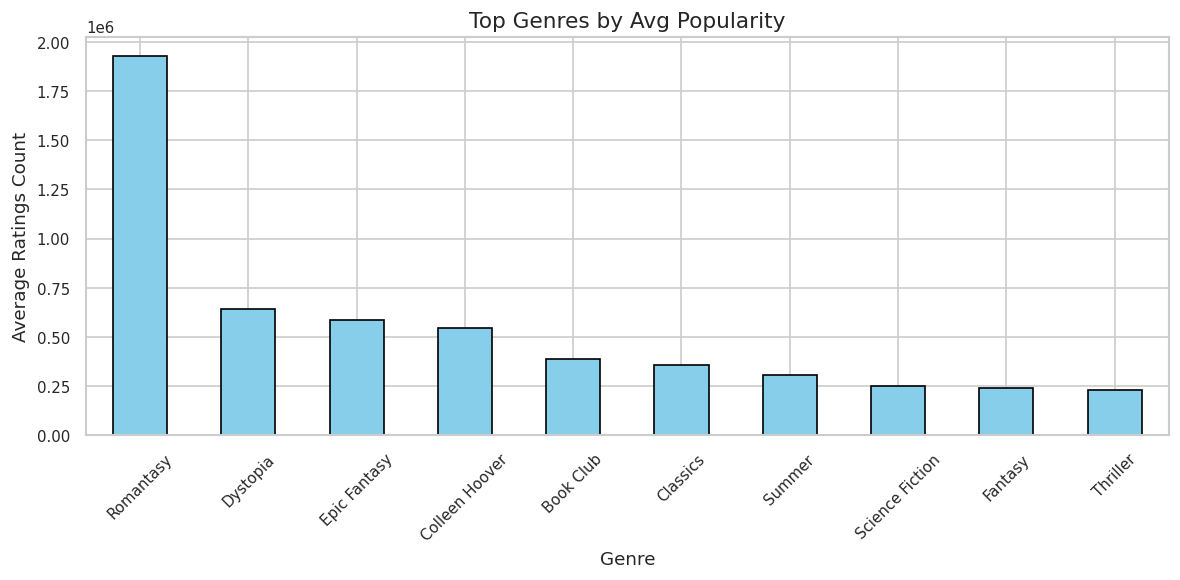

In [18]:
# genre vs popularity
genre_df = (
    df[['genre', 'ratings_count']]
    .dropna(subset=['genre'])
    .assign(genre_list=df['genre'].str.split(','))
    .explode('genre_list')
)

genre_df['genre_list'] = genre_df['genre_list'].str.strip()

genre_pop = (
    genre_df
    .groupby('genre_list')['ratings_count']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

genre_pop.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Top Genres by Avg Popularity")
plt.ylabel("Average Ratings Count")
plt.xlabel("Genre")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- the genre column contains multiple values per entry, leading to a large number of unique combinations and making direct analysis difficult. So this will be handled  in the preprocessing stage using multi-label encoding.

- genre column contains noisy data — some rows include author names mixed with genres

In [19]:
import re

# Cleaning function
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9 ]', '', text)
    return text

# Clean author names
authors_clean = set(
    df['author']
    .dropna()
    .apply(clean_text)
)

# Clean exploded genres
genre_df['genre_clean'] = genre_df['genre_list'].apply(clean_text)

# Find matching author names inside genres
author_in_genre = genre_df[
    genre_df['genre_clean'].isin(authors_clean)
]

# Total matches
print("Total rows with author names in genres:")
print(len(author_in_genre))

# Unique invalid genre values
print("\nUnique author names found inside genres:")
print(author_in_genre['genre_list'].drop_duplicates().tolist())

Total rows with author names in genres:
22

Unique author names found inside genres:
['Colleen Hoover', 'Agatha Christie', 'Jane Austen']


#### Publishers

In [20]:
total_publisher_count = df['publisher'].nunique()
print(f"Total unique publishers: {total_publisher_count}")

Total unique publishers: 643


In [21]:
import re

publisher_patterns = {
    'HarperCollins': [r'harper'],
    'Penguin': [r'penguin'],
    'Random House': [r'random house'],
    'CreateSpace': [r'createspace'],
    'Simon & Schuster': [r'simon']
}

def normalize_publisher(pub):

    if pd.isna(pub):
        return pub

    pub_lower = pub.lower()

    for standard_name, patterns in publisher_patterns.items():

        for pattern in patterns:

            if re.search(pattern, pub_lower):
                return standard_name

    return pub.title()

In [22]:
df['publisher_clean'] = df['publisher'].apply(normalize_publisher)

In [23]:
publisher_count_clean = df['publisher_clean'].nunique()
print(f"Total unique cleaned publishers: {publisher_count_clean}")

Total unique cleaned publishers: 607


In [24]:
df['publisher_clean'].value_counts().head(10)

,count
publisher_clean,
HarperCollins,728
Mills & Boon,393
Penguin,256
Scholastic,217
Simon & Schuster,125
Hachette Uk,120
CreateSpace,102
Random House,64
Orbit,37


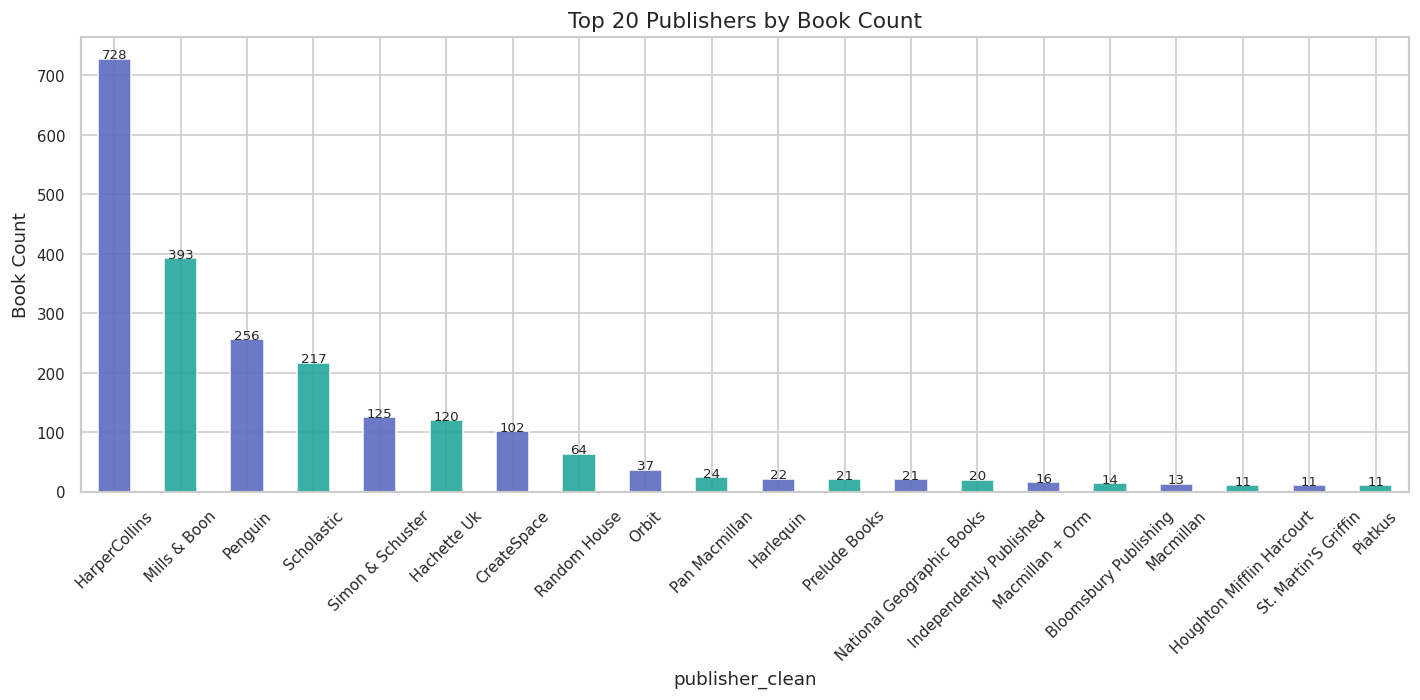

In [25]:
top20_pub = df['publisher_clean'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#5C6BC0' if i % 2 == 0 else '#26A69A' for i in range(len(top20_pub))]
top20_pub.plot(kind='bar', ax=ax, color=colors, edgecolor='white', alpha=0.9)
ax.set_ylabel('Book Count')
ax.set_title('Top 20 Publishers by Book Count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(top20_pub):
    ax.text(i, v+0.5, str(v), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

#### Language

In [26]:
total_lang = df['language'].value_counts()
print("Number of Languages :\n", len(total_lang))
print("\nTop languages:\n", total_lang.head(10))

Number of Languages :
 22

Top languages:
 language
en    2039
ar     451
hi      28
tr      24
ta      19
de      14
bn      14
es       9
kn       8
id       7
Name: count, dtype: int64


    'en':'English', 'ar':'Arabic',  'hi':'Hindi',    'tr':'Turkish',
    'ta':'Tamil',   'de':'German',  'bn':'Bengali',  'es':'Spanish',
    'kn':'Kannada', 'id':'Indonesian','it':'Italian','fr':'French',
    'ml':'Malayalam','te':'Telugu', 'da':'Danish',   'ur':'Urdu',
    'ja':'Japanese','zh':'Chinese', 'ru':'Russian',  'pt':'Portuguese',
    'nl':'Dutch',   'ko':'Korean',  'pl':'Polish',   'sv':'Swedish',
    'no':'Norwegian','fi':'Finnish'

### Numerical data

#### Pages

In [27]:
max_pg = df['pages'].max()
min_pg = df['pages'].min()
print(f"Max pages: {max_pg}")
print(f"Min pages: {min_pg}")

Max pages: 1867
Min pages: 6


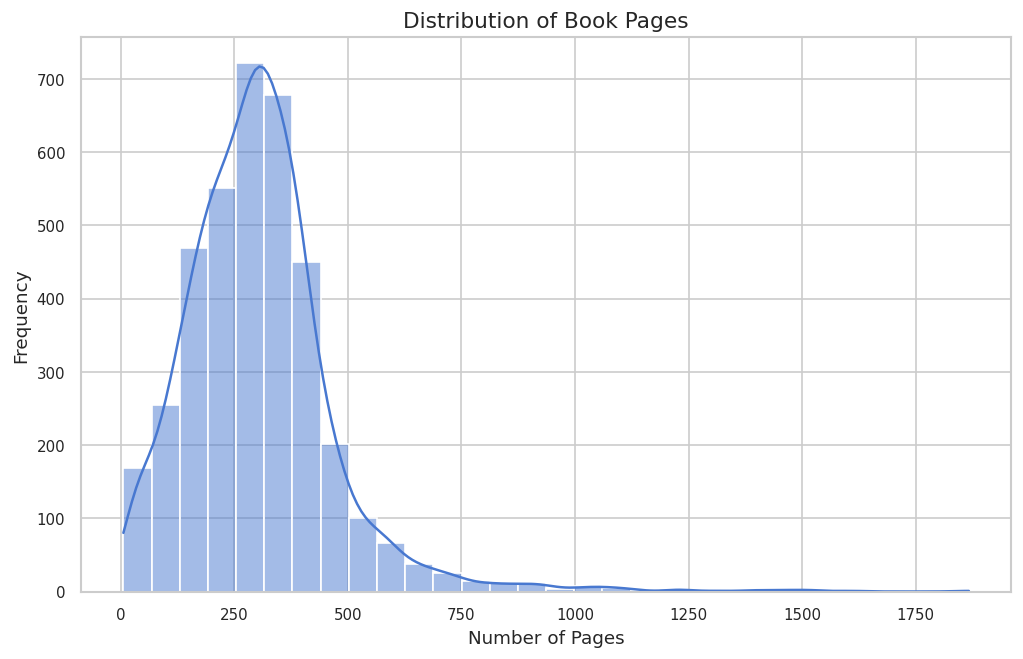

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df['pages'], bins=30, kde=True)
plt.title('Distribution of Book Pages')
plt.xlabel('Number of Pages')
plt.ylabel('Frequency')
plt.show()

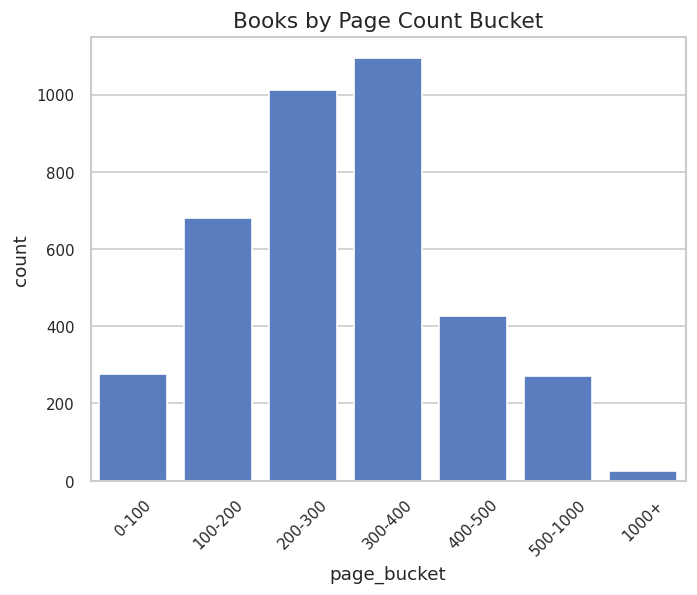

In [29]:
df['page_bucket'] = pd.cut(
    df['pages'],
    bins=[0, 100, 200, 300, 400, 500, 1000, float('inf')],
    labels=['0-100', '100-200', '200-300', '300-400', '400-500', '500-1000', '1000+']
)
sns.countplot(data=df, x='page_bucket')
plt.xticks(rotation=45)
plt.title('Books by Page Count Bucket')
plt.show()

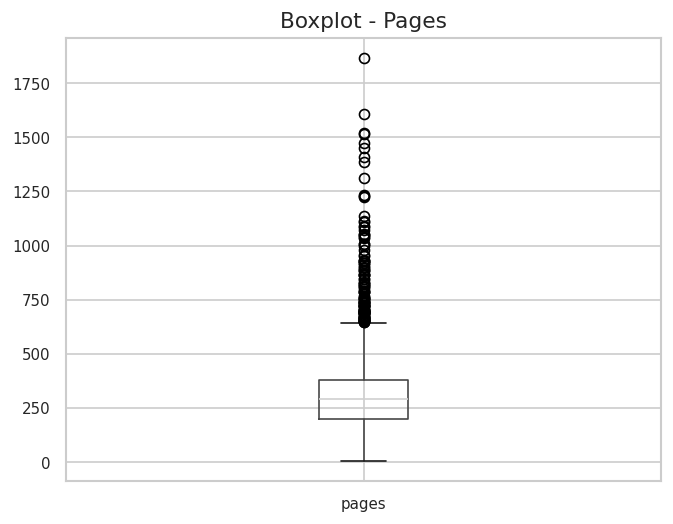

In [30]:
#outliers in pages
plt.figure()
df.boxplot(column='pages')
plt.title("Boxplot - Pages")
plt.show()

In [31]:
pg_below_10 = df[df['pages'] < 10][['title', 'pages']]
print("Books with page count below 10:\n", pg_below_10)
print(f"Number of books with page count below 10: {len(pg_below_10)}")

Books with page count below 10:
                                        title  pages
53                          Savor the Moment      9
1139  A Lady's Guide to Etiquette and Murder      9
2287                            البيت المسلم      8
2301                          السيرة النبوية      6
2304                       دورة الوعي اللغوي      8
3752                                    कफ़न      7
Number of books with page count below 10: 6


For some of the books with pages below 10  the entries are wrong ,this was found out manually . These value will be hard-coded with verified values during the Preprocessing

In [32]:
print("\nTop 10 longest books:")
display(df.nlargest(10,'pages')[['title','author','pages','genre']])

# Year flags
print(f"\nFuture years (>2026): {(df['year'] > 2026).sum()}")
print(f"Very old  (<1500)   : {(df['year'] < 1500).sum()}")
df['year_flag'] = ~df['year'].between(1500, 2026)

# Log-transform ratings count for analysis
df['log_ratings'] = np.log1p(df['ratings_count'])
print(f"\nratings_count range: {df['ratings_count'].min():,} → {df['ratings_count'].max():,}")


Top 10 longest books:


,title,author,pages,genre
1749,موسوعة أسماء الله الحسنى,محمد راتب النابلسي,1867,"Religion, Islam, Faith"
1628,أنت لي,منى المرشود,1607,"Novels, Romance, Fiction"
3020,The Mortal Instruments Boxed Set: City of Bone...,Cassandra Clare,1520,"Fantasy, Young Adult, Romance"
2313,النظريات العلمية الحديثة - مسيرتها الفكرية وأس...,حسن بن محمد حسن الأسمري,1515,Science
3584,A Suitable Boy,Vikram Seth,1474,"Fiction, India, Historical Fiction"
3744,"பொன்னியின் செல்வன், முழுத்தொகுப்பு",Kalki Krishnamurthy,1452,"Fiction, Historical Fiction, Classics"
3741,"வீரயுக நாயகன் வேள்பாரி, முழுத்தொகுப்பு",Su. Venkatesan,1408,"Fiction, Indian Literature, Historical Fiction"
1706,تاريخ أوروبا والعالم في العصر الحديث، الجزء الأول,عبد العظيم رمضان,1386,History
1738,"The Cairo Trilogy: Palace Walk, Palace of Desi...",Naguib Mahfouz,1313,"Fiction, Historical Fiction, Egypt"
1101,Gai-Jin,James Clavell,1236,"Historical Fiction, Fiction, Japan"



Future years (>2026): 0
Very old  (<1500)   : 0

ratings_count range: 1 → 11,590,973


#### Year

In [33]:
years_max = df['year'].max()
years_min = df['year'].min()
print(f"Max year: {years_max}")
print(f"Min year: {years_min}")

Max year: 2025
Min year: 1811


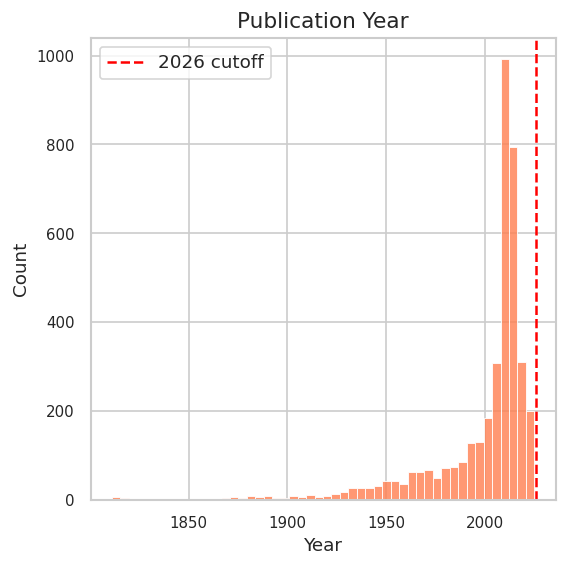

In [34]:
yr = df['year'].dropna().astype(int)
yr = yr[yr.between(1800, 2026)]
plt.figure(figsize=(5, 5))
sns.histplot(yr,bins=50,color='coral',edgecolor='white',alpha=0.8)

plt.axvline(2026,color='red',linestyle='--',linewidth=1.5,label='2026 cutoff')

plt.legend()
plt.title('Publication Year')
plt.xlabel('Year')

plt.show()

#### Rating - score given by readers.

In [35]:
rat_max = df['rating'].max()
rat_min = df['rating'].min()
print(f"Max rating: {rat_max}")
print(f"Min rating: {rat_min}")

Max rating: 5.0
Min rating: 2.0


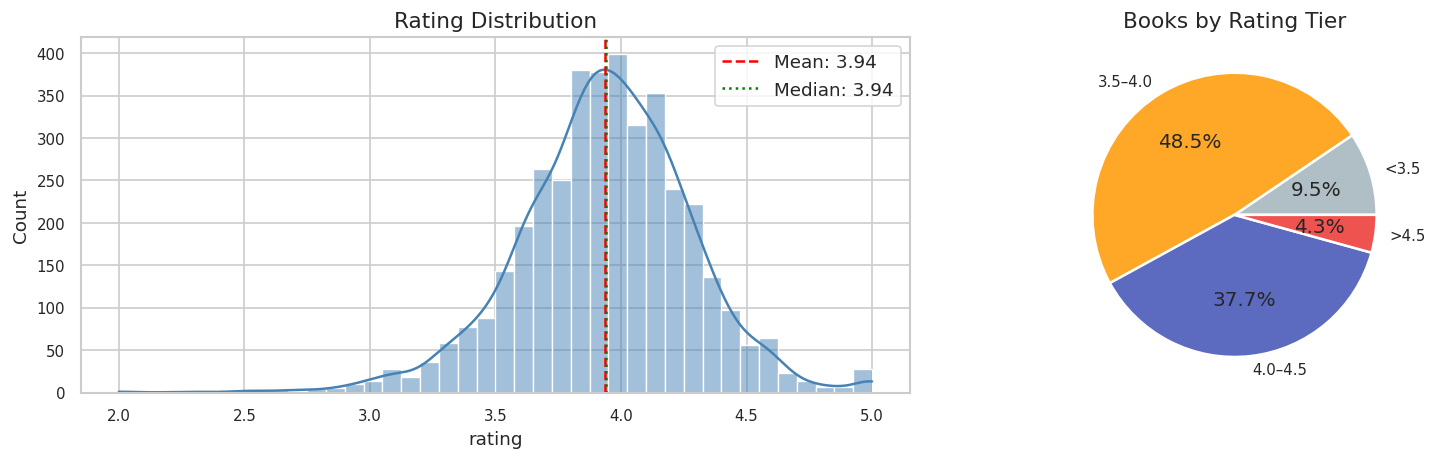

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['rating'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['rating'].mean(),   color='red',   linestyle='--', lw=1.5, label=f'Mean: {df["rating"].mean():.2f}')
axes[0].axvline(df['rating'].median(), color='green', linestyle=':',  lw=1.5, label=f'Median: {df["rating"].median():.2f}')
axes[0].legend(); axes[0].set_title('Rating Distribution')

df['rating_tier'] = pd.cut(df['rating'], bins=[0,3.5,4.0,4.5,5.0],
                            labels=['<3.5','3.5–4.0','4.0–4.5','>4.5'])
tier_counts = df['rating_tier'].value_counts().sort_index()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['#B0BEC5','#FFA726','#5C6BC0','#EF5350'],
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Books by Rating Tier')

plt.tight_layout(); plt.show()

#### Rating count - Total number of people who rated the book

In [37]:
rat_count_max = df['ratings_count'].max()
rat_count_min = df['ratings_count'].min()
print(f"Max rating count: {rat_count_max}")
print(f"Min rating count: {rat_count_min}")

Max rating count: 11590973
Min rating count: 1


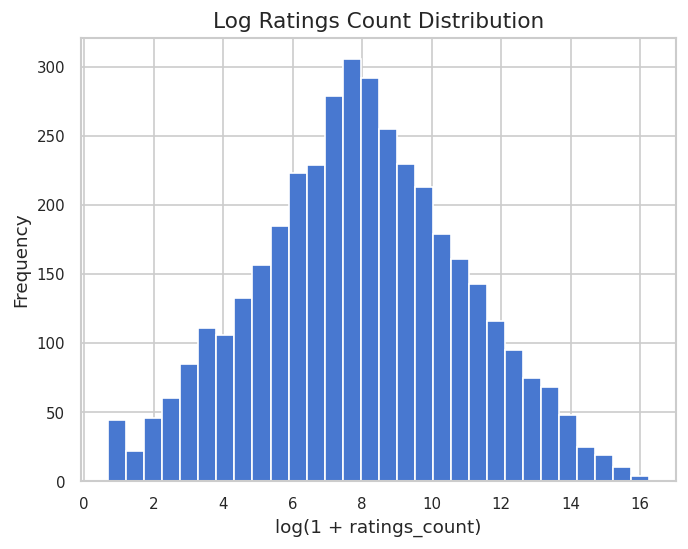

In [38]:
plt.figure()
np.log1p(df['ratings_count']).hist(bins=30)
plt.title("Log Ratings Count Distribution")
plt.xlabel("log(1 + ratings_count)")
plt.ylabel("Frequency")
plt.show()

#### Review count - Number of written reviews

In [39]:
review_count_max = df['reviews_count'].max()
review_count_min = df['reviews_count'].min()
print(f"Max review count: {review_count_max}")
print(f"Min review count: {review_count_min}")

Max review count: 326656
Min review count: 0


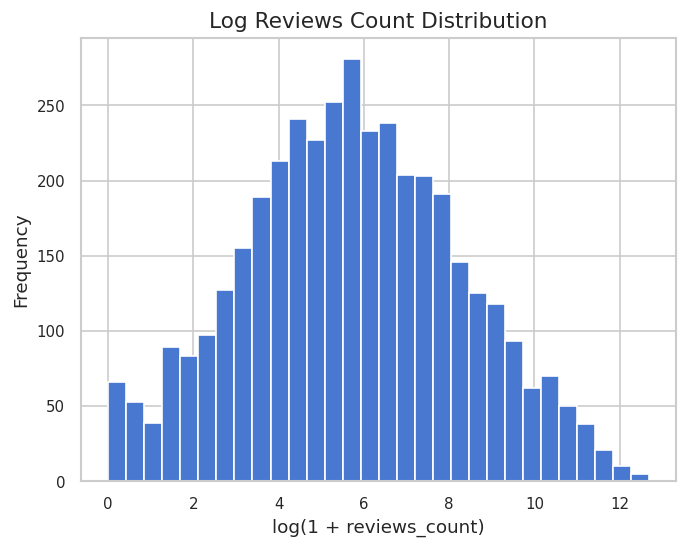

In [40]:
plt.figure()
np.log1p(df['reviews_count']).hist(bins=30)
plt.title("Log Reviews Count Distribution")
plt.xlabel("log(1 + reviews_count)")
plt.ylabel("Frequency")
plt.show()

#### Price

In [41]:
max_price = df['price'].max()
min_price = df['price'].min()
print(f"Max price: {max_price}")
print(f"Min price: {min_price}")

Max price: 5806.78
Min price: 0.0


In [42]:
print(f"Price = 0  : {(df['price'] == 0).sum()} rows")
print(f"Price > 3000: {(df['price'] > 3000).sum()} rows")

# Inspect extremes
print("\nMost expensive books:")
display(df.nlargest(10, 'price')[['title','author','price','publisher_clean']])

# Treat price = 0 as missing
#df.loc[df['price'] == 0, 'price'] = np.nan

Price = 0  : 20 rows
Price > 3000: 5 rows

Most expensive books:


,title,author,price,publisher_clean
3685,ഗുരുസാഗരം | Gurusagaram,ഒ.വി.വിജയൻ | O.V.Vijayan,5806.78,Taylor & Francis
2209,‫هكذا علمتني الحياة‬,مصطفى السباعي,3914.75,Ktab Inc.
2372,Life As We Knew It,Susan Beth Pfeffer,3749.78,HarperCollins
966,Jet,Jay Crownover,3678.67,HarperCollins
3678,രണ്ടിടങ്ങഴി | Randidangazhi,തകഴി |Thakazhi Sivasankara Pillai,3138.80,Routledge
1998,حياتي,أحمد أمين,2572.23,Ktab Inc.
1254,Murder in an Italian Village,Michael Falco,2567.49,Kensington Cozies
1289,Murder at the Majestic Hotel,Clara McKenna,2472.68,Kensington Books
1594,في صالون العقاد كانت لنا أيام,أنيس منصور,2465.09,Nahdet Misr Publishing Group
1578,عبقرية محمد,عباس محمود العقاد,2236.60,Ktab Inc.


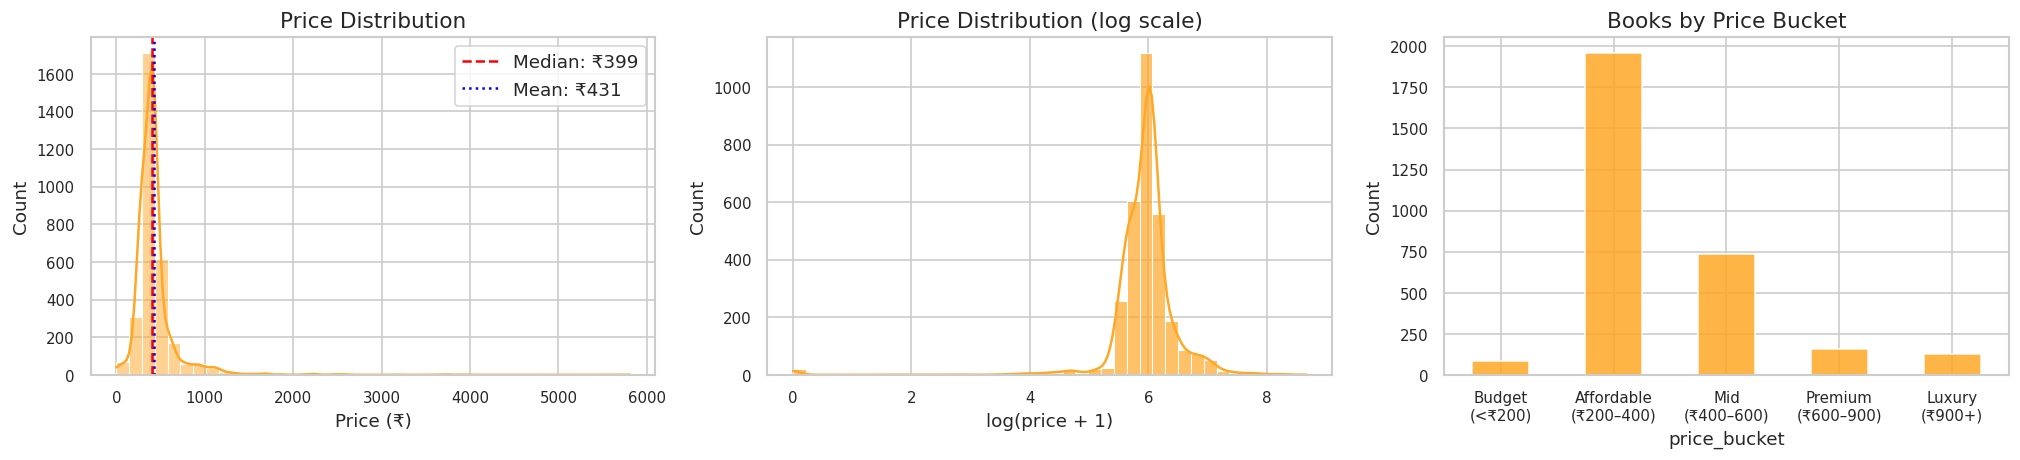

count    3078.00
mean      431.35
std       267.29
min         0.00
25%       299.00
50%       399.00
75%       450.00
max      5806.78
Name: price, dtype: float64

Skewness : 6.939
Coverage : 3078 / 3919 books (78.5%)


In [43]:
price_clean = df['price'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Histogram
sns.histplot(price_clean, bins=40, kde=True, ax=axes[0], color='#FFA726')
axes[0].axvline(price_clean.median(), color='red', linestyle='--', lw=1.5,
                label=f'Median: ₹{price_clean.median():.0f}')
axes[0].axvline(price_clean.mean(), color='blue', linestyle=':', lw=1.5,
                label=f'Mean: ₹{price_clean.mean():.0f}')
axes[0].legend(); axes[0].set_xlabel('Price (₹)')
axes[0].set_title('Price Distribution')

# Log scale
sns.histplot(np.log1p(price_clean), bins=40, kde=True, ax=axes[1], color='#FFA726', alpha=0.7)
axes[1].set_xlabel('log(price + 1)'); axes[1].set_title('Price Distribution (log scale)')

# Price buckets
df['price_bucket'] = pd.cut(df['price'],
    bins=[0, 200, 400, 600, 900, 10000],
    labels=['Budget\n(<₹200)', 'Affordable\n(₹200–400)',
            'Mid\n(₹400–600)', 'Premium\n(₹600–900)', 'Luxury\n(₹900+)'])
df['price_bucket'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='#FFA726', edgecolor='white', alpha=0.85)
axes[2].set_title('Books by Price Bucket')
axes[2].set_ylabel('Count'); axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

print(price_clean.describe().round(2))
print(f"\nSkewness : {price_clean.skew():.3f}")
print(f"Coverage : {len(price_clean)} / {len(df)} books ({len(price_clean)/len(df)*100:.1f}%)")

/tmp/ipykernel_506/1381177538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_rating = df.groupby('price_bucket')['rating'].mean()


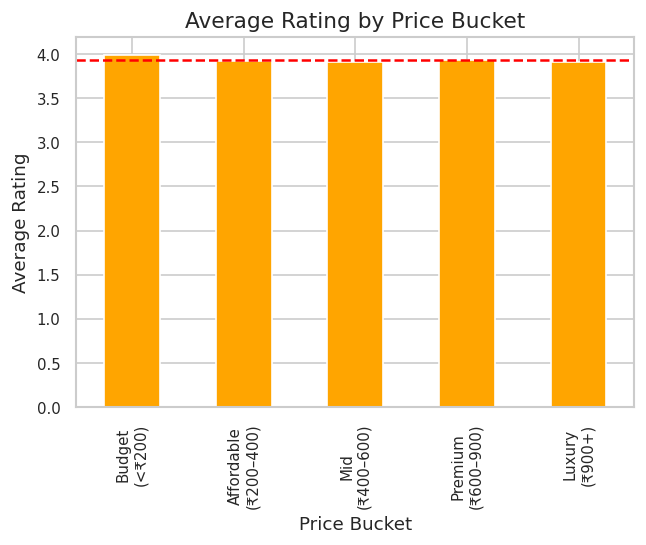

In [44]:
bucket_rating = df.groupby('price_bucket')['rating'].mean()

plt.figure(figsize=(6,4))

bucket_rating.plot(
    kind='bar',
    color='orange'
)

plt.xlabel("Price Bucket")
plt.ylabel("Average Rating")
plt.title("Average Rating by Price Bucket")

plt.axhline(df['rating'].mean(), color='red', linestyle='--')

plt.show()

## Bivaraite Analysis

#### Price vs Rating

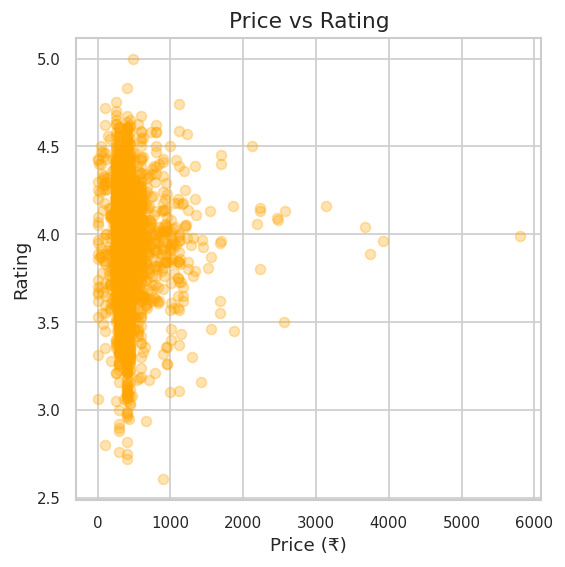

In [45]:
plt.figure(figsize=(5,5))

plt.scatter(
    df['price'],
    df['rating'],
    alpha=0.3,
    color='orange'
)

plt.xlabel("Price (₹)")
plt.ylabel("Rating")
plt.title("Price vs Rating")

plt.show()

Ratings appear relatively independent of book pricing

#### Rating vs popularity

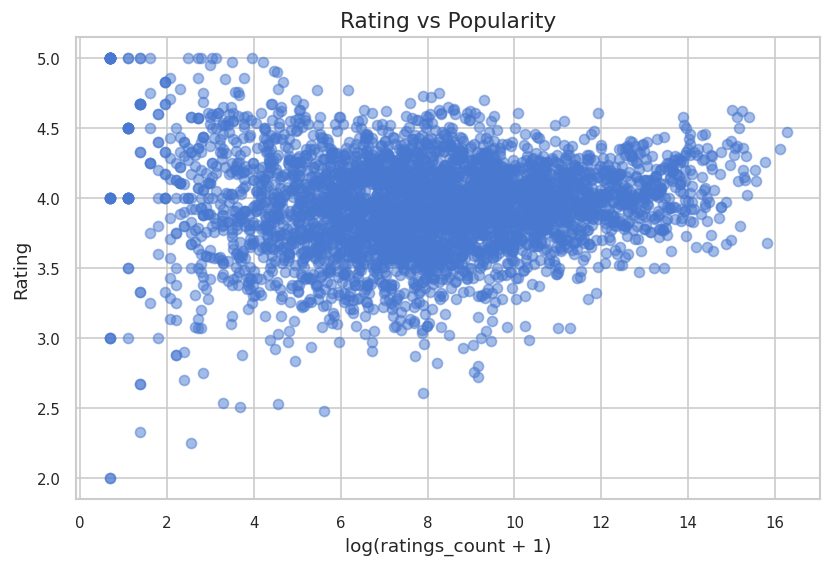

In [46]:
plt.figure(figsize=(8, 5))

plt.scatter(df['log_ratings'],df['rating'],alpha=0.5)

# Labels and title
plt.xlabel('log(ratings_count + 1)')
plt.ylabel('Rating')
plt.title('Rating vs Popularity')

plt.show()

#### Genre vs Rating

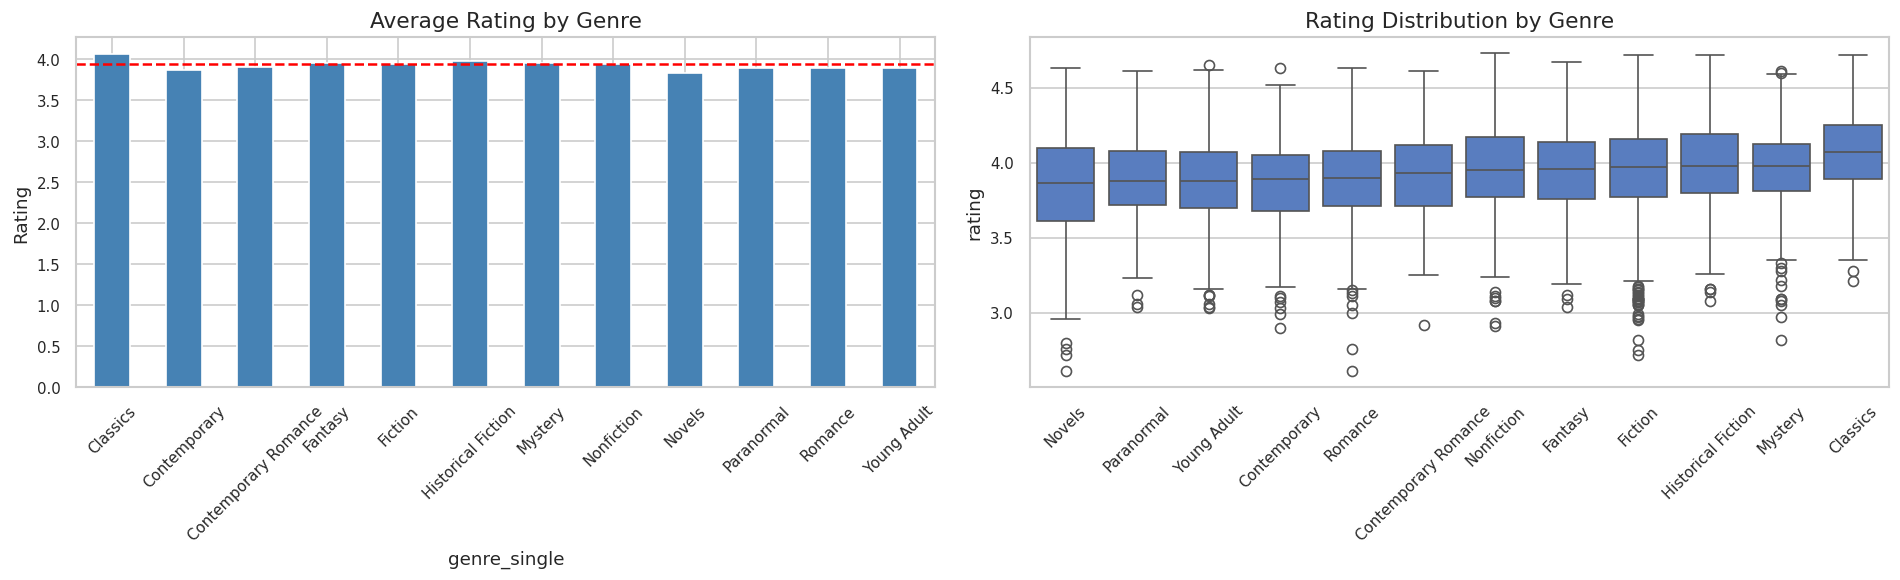

In [47]:
top12 = genres_exploded.value_counts().head(12).index.tolist()

df_exp = df.copy()

df_exp['genre_single'] = df_exp['genre'].str.split(',')
df_exp = df_exp.explode('genre_single')

df_exp['genre_single'] = df_exp['genre_single'].str.strip()

df_top = df_exp[df_exp['genre_single'].isin(top12)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

genre_avg = df_top.groupby('genre_single')['rating'].mean()

genre_avg.plot(kind='bar',ax=axes[0],color='steelblue')
axes[0].axhline(df['rating'].mean(),color='red',linestyle='--')
axes[0].set_title("Average Rating by Genre")
axes[0].set_ylabel("Rating")
axes[0].tick_params(axis='x', rotation=45)

order = df_top.groupby('genre_single')['rating'].median().sort_values().index

sns.boxplot(data=df_top,x='genre_single',y='rating',order=order,ax=axes[1])

axes[1].set_title("Rating Distribution by Genre")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


- Genre alone doesn't explain rating differences

#### Pages vs genre and rating

/tmp/ipykernel_506/3407221025.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=top8)


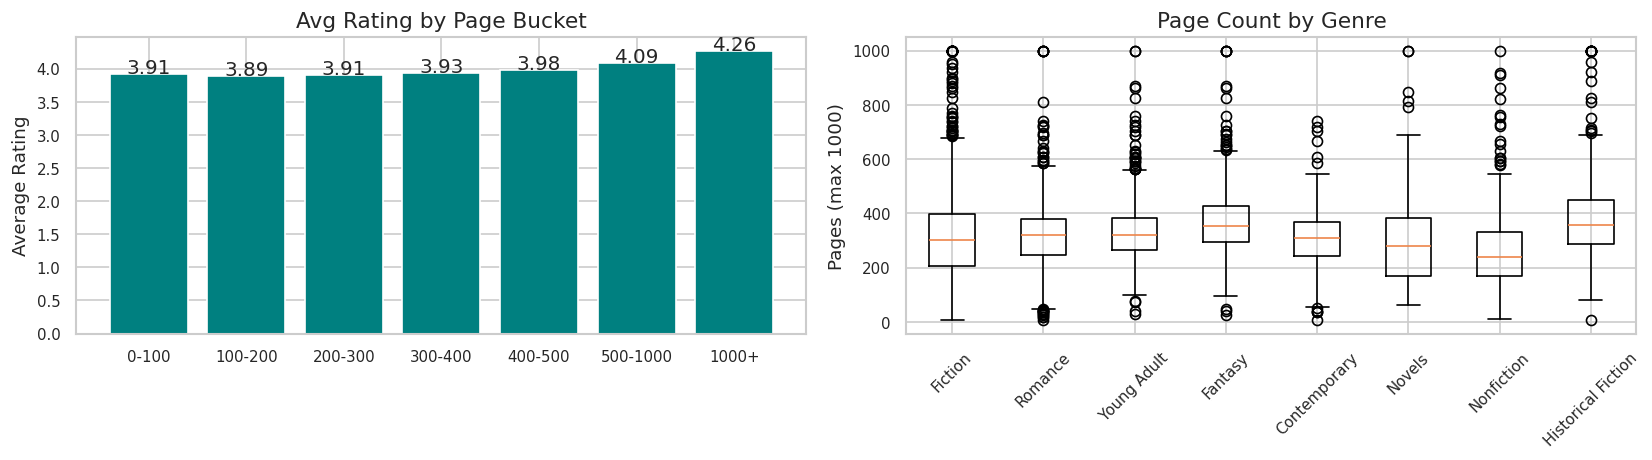

In [48]:
page_rating = (
    df.dropna(subset=['page_bucket', 'rating'])
      .groupby('page_bucket', observed=True)
      .agg(avg_rating=('rating', 'mean'),
           count=('rating', 'count'))
      .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    page_rating['page_bucket'].astype(str),
    page_rating['avg_rating'],
    color='teal'
)

axes[0].set_title("Avg Rating by Page Bucket")
axes[0].set_ylabel("Average Rating")

# show values on top
for i, v in enumerate(page_rating['avg_rating']):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha='center')
top8 = genres_exploded.value_counts().head(8).index.tolist()

box_data = []

for g in top8:
    values = df_exp[df_exp['genre_single'] == g]['pages']
    values = values.dropna().clip(upper=1000)
    box_data.append(values)
axes[1].boxplot(box_data, labels=top8)

axes[1].set_title("Page Count by Genre")
axes[1].set_ylabel("Pages (max 1000)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

- There is a small upward trend for rating as books get longer
- Different genres exhibit different page count distributions

#### Popularity vs publication year

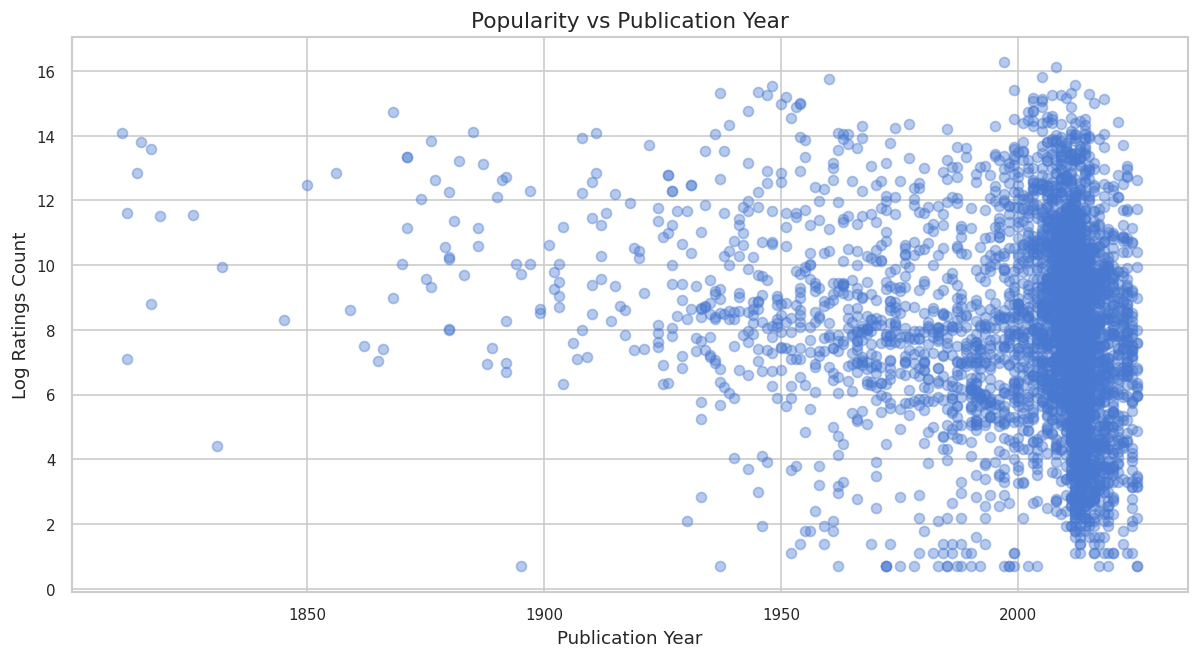

In [49]:
plt.figure(figsize=(12,6))

plt.scatter(
    df['year'],
    df['log_ratings'],
    alpha=0.4
)

plt.title('Popularity vs Publication Year')
plt.xlabel('Publication Year')
plt.ylabel('Log Ratings Count')

plt.show()

The relationship between publication year and popularity appears weak overall, as books from both older and newer periods exhibit a wide range of popularity levels

#### Rating vs rating count

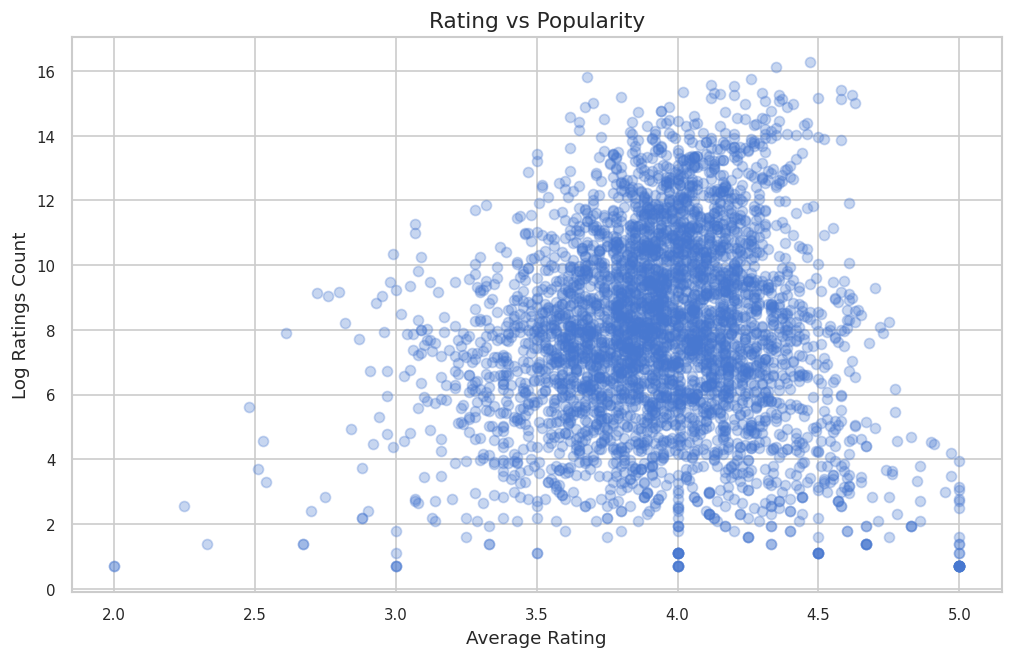

In [50]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['rating'],
    df['log_ratings'],
    alpha=0.3
)

plt.xlabel('Average Rating')
plt.ylabel('Log Ratings Count')
plt.title('Rating vs Popularity')

plt.show()

- Average rating alone does not strongly determine book popularity, as books with similar ratings exhibit widely different popularity levels
- Some books with high average ratings have relatively low ratings counts, while some widely popular books maintain only moderate ratings

#### Reviews Count vs Ratings Count

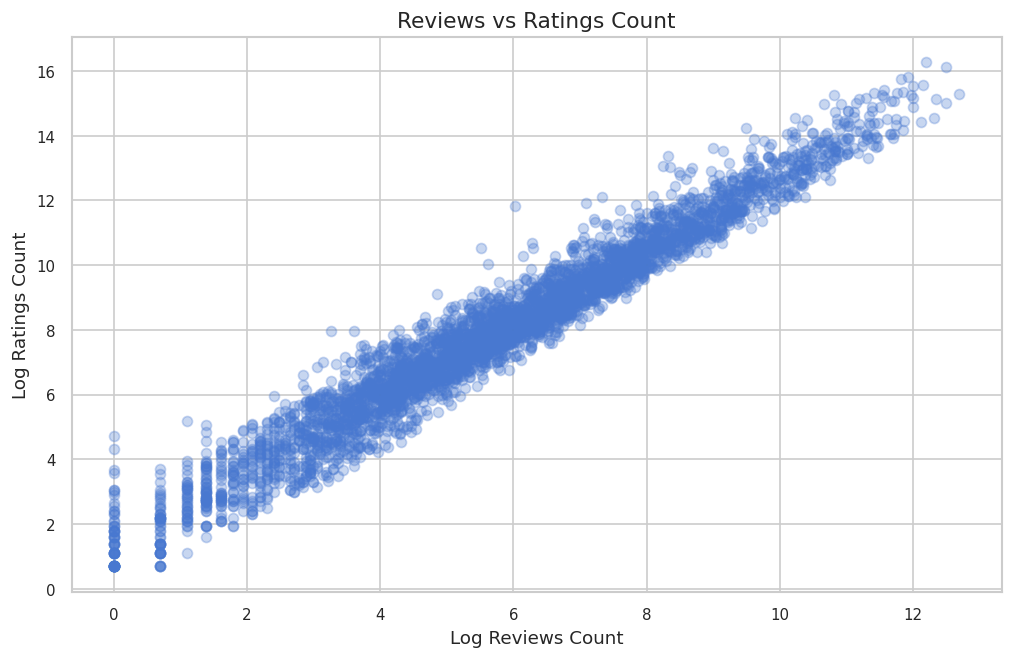

In [51]:
df['log_reviews_count'] = np.log1p(df['reviews_count'])
plt.figure(figsize=(10,6))

plt.scatter(
    df['log_reviews_count'],
    df['log_ratings'],
    alpha=0.3
)

plt.xlabel('Log Reviews Count')
plt.ylabel('Log Ratings Count')
plt.title('Reviews vs Ratings Count')

plt.show()

Books with higher ratings counts generally also receive higher review counts, indicating a strong positive relationship between readership size and reader engagement

### Correlation Heatmap

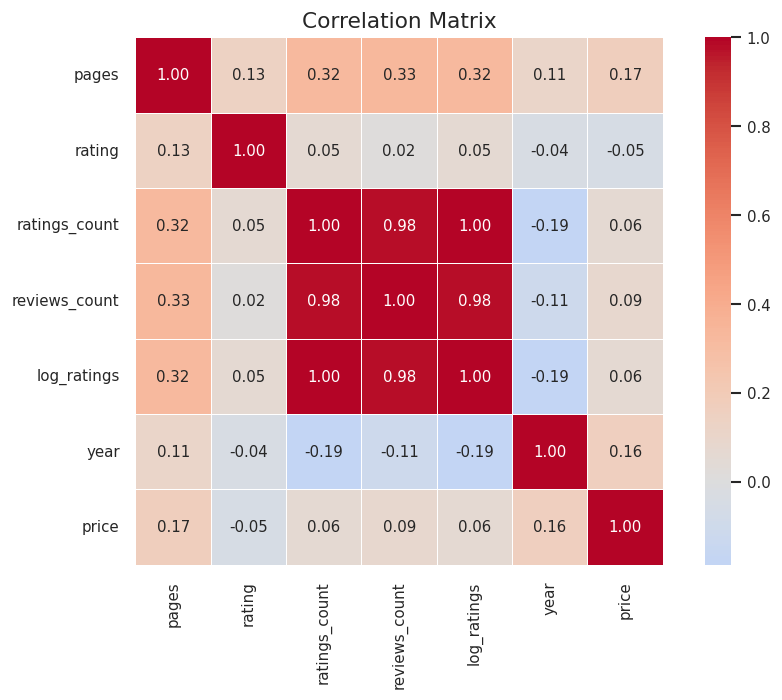

In [52]:
num_cols = ['pages','rating','ratings_count','reviews_count','log_ratings','year','price']
corr = df[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size':9}, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout(); plt.show()

- Ratings count and reviews count exhibit an extremely strong positive correlation, indicating that books with larger readership generally generate more reader discussions and written engagement
- Page count shows a moderate positive correlation with popularity-related features
- Publication year exhibits weak negative correlation

### Popularity Metrics

In [53]:
# Defining the Popularity Metric
df['review_rate'] = (
    df['reviews_count'] /
    (df['ratings_count'] + 1) # +1 is added to avoid divison by 0
)
# Normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

log_ratings_scaled = scaler.fit_transform(
    df[['log_ratings']]
).flatten()

review_rate_scaled = scaler.fit_transform(
    df[['review_rate']]
).flatten()

# Composite popularity score
# 70% audience reach + 30% engagement quality
df['pop_score'] = (
    0.7 * log_ratings_scaled +
    0.3 * review_rate_scaled
)

| Metric        | Represents            |
| ------------- | --------------------- |
| ratings_count | reach / audience size |
| review_rate   | engagement intensity  |


In [54]:
df['pop_score'].describe()

,pop_score
count,3919.000000
mean,0.371645
std,0.119846
min,0.000000
25%,0.298234
50%,0.369195
75%,0.450542
max,0.705907


<Axes: >

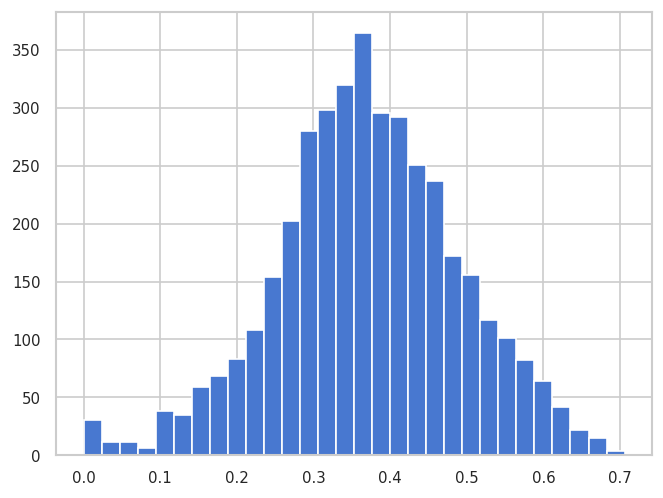

In [55]:
df['pop_score'].hist(bins=30)

In [56]:
# target
df['popularity_tier'] = pd.qcut(
    df['pop_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
# class balance of target
print(df['popularity_tier'].value_counts())

popularity_tier
Low       1307
High      1307
Medium    1305
Name: count, dtype: int64


## Data Preprocessing And Feature Engineering

In [57]:
df.columns

Index(['title', 'author', 'genre', 'pages', 'rating', 'ratings_count',
       'reviews_count', 'year', 'publisher', 'language', 'description',
       'price', 'publisher_clean', 'page_bucket', 'year_flag', 'log_ratings',
       'rating_tier', 'price_bucket', 'log_reviews_count', 'review_rate',
       'pop_score', 'popularity_tier'],
      dtype='object')

In [58]:
checks = {
    'reviews_count > ratings_count' : (df['reviews_count'] > df['ratings_count']).sum(),
    'rating outside [1, 5]'         : (~df['rating'].between(1, 5)).sum(),
    'pages <= 0'                    : (df['pages'] <= 0).sum(),
    'ratings_count == 0'            : (df['ratings_count'] == 0).sum(),
    'encoding issues (title)'       : df['title'].str.contains(r'â€|Ã©|Ã¢', na=False).sum(),
    'encoding issues (author)'      : df['author'].str.contains(r'â€|Ã©|Ã¢', na=False).sum(),
}

all_pass = True
for check, count in checks.items():
    status = 'Ok' if count == 0 else 'Failed'
    if count > 0: all_pass = False
    print(f"  {status}  {check}: {count}")

print(f"\n{'All checks passed' if all_pass else 'Some checks failed — review above'}")

  Ok  reviews_count > ratings_count: 0
  Ok  rating outside [1, 5]: 0
  Ok  pages <= 0: 0
  Ok  ratings_count == 0: 0
  Ok  encoding issues (title): 0
  Ok  encoding issues (author): 0

All checks passed


#### Page


In [59]:
# books with wrong page entry hard coded
page_corrections = {
    "Savour the Moment": 352,
    "Noughts & Crosses": 478,
    "A Lady's Guide to Etiquette and Murder": 290,
    "Waiting for the Flood": 379,
    "A Princess in Boxland": 32,
    "السيرة النبوية": 704,
    "मधुशाला": 135
}

for title, pages in page_corrections.items():

    df.loc[
        df['title'].str.contains(
            title,
            case=False,
            na=False
        ),
        'pages'
    ] = pages


#### Language

In [60]:
# language
!pip install langdetect
from langdetect import detect,DetectorFactory
DetectorFactory.seed = 0 # stabilize langdetect

LANG_MAP = {
    'en':'English','ar':'Arabic','hi':'Hindi','tr':'Turkish','ta':'Tamil',
    'de':'German','bn':'Bengali','es':'Spanish','kn':'Kannada','id':'Indonesian',
    'it':'Italian','fr':'French','ml':'Malayalam','te':'Telugu','da':'Danish',
    'ur':'Urdu','ja':'Japanese','zh-cn':'Chinese','ru':'Russian','pt':'Portuguese',
    'pt-BR':'Portuguese','nl':'Dutch','ko':'Korean','fa':'Persian','mr':'Marathi',
    'cs':'Czech','fi':'Finnish',
}

def detect_lang(row):
  for text in [row.get('description'),row.get('title')]:
    if pd.notna(text):
      text = str(text).strip()

      if len(text)>5 :
        try :
          return detect(text)
        except Exception :
          continue
  return None



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f7220fd8162294adb4f1b55e84c02b51bf9fbe14c538c1352159253dfa446ac8
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


#### Language

In [61]:
missing_lang = df['language'].isna()
df.loc[missing_lang, 'language'] = (
        df[missing_lang].apply(detect_lang, axis=1)
    )

df['language_name'] = df['language'].map(LANG_MAP).fillna(df['language'])

In [62]:
display(df['language_name'].value_counts().head(12).to_frame())

,count
language_name,
English,2851
Arabic,794
Tamil,43
Hindi,37
Malayalam,27
Bengali,26
Turkish,25
Telugu,24
German,17


#### Genre

In [63]:
invalid_genres = [
    'Colleen Hoover',
    'Agatha Christie',
    'Jane Austen'
]

In [64]:
# remove author names from genre
def remove_invalid_genres(genre_string):

    if pd.isna(genre_string):
        return genre_string

    genres = [
        g.strip()
        for g in genre_string.split(',')
    ]

    cleaned = [
        g for g in genres
        if g not in invalid_genres
    ]

    return ', '.join(cleaned)

df['genre'] = df['genre'].apply(remove_invalid_genres)
df['genre'] = df['genre'].replace('', np.nan) # return nan as some rows may only have author name as genre

In [65]:
missing_genre_pct = (
    df['genre'].isnull().mean() * 100
)

print(f"Missing genre percentage: {missing_genre_pct:.2f}%")

Missing genre percentage: 8.29%


In [66]:
df['author'] = (
    df['author']
    .fillna('unknown')
    .str.strip()
    .str.lower()
)

df['publisher'] = df['publisher'].fillna('unknown')

df['publisher'] = (
    df['publisher']
    .str.strip()
    .str.lower()
)

In [67]:
df['price'].describe(percentiles=[0.90,0.95,0.99])

,price
count,3078.000000
mean,431.345214
std,267.289442
min,0.000000
50%,399.000000
90%,599.000000
95%,831.908000
99%,1341.798500
max,5806.780000


In [68]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['popularity_tier','ratings_count',	'reviews_count','log_ratings','log_reviews_count','review_rate','pop_score'])
y = df['popularity_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
X_train.head()

,title,author,genre,pages,rating,year,publisher,language,description,price,publisher_clean,page_bucket,year_flag,rating_tier,price_bucket,language_name
2962,The annals of murder;: A bibliography of books...,thomas m. mcdade,NaN,360,4.60,1961,unknown,en,Over 1100 numbered entries for publications th...,NaN,NaN,300-400,False,>4.5,NaN,English
1814,أن تبقى,khaoula hamdi,"Novels, Fiction, Romance",383,3.87,2016,harpercollins,ar,كان كل شيء باردا وخاليا من الإثارة حتى تلك الل...,399.0,HarperCollins,300-400,False,3.5–4.0,Affordable\n(₹200–400),Arabic
1653,قذائف الحق,muhammad al-ghazali,"Religion, Islam, Politics",304,4.21,1991,kazi publications,en,"من أهم كتب الشيخ الغزالى,ممنوع من النشر فى أغل...",NaN,Kazi Publications,300-400,False,4.0–4.5,NaN,English
2545,The Replacement,brenna yovanoff,"Young Adult, Fantasy, Horror",343,3.56,2010,penguin,en,Mackie Doyle is not one of us. Though he lives...,450.0,Penguin,300-400,False,3.5–4.0,Mid\n(₹400–600),English
3442,Mr. and Mrs. Bo Jo Jones,ann head,"Young Adult, Fiction, Classics",208,3.83,1967,penguin classics,en,Football hero Bo Jo Jones and his girlfriend J...,250.0,Penguin,200-300,False,3.5–4.0,Affordable\n(₹200–400),English


#### Null filling - page,year and price

In [70]:
page_median = X_train['pages'].median()
year_median = X_train['year'].median()
price_median = X_train['price'].median()


X_train['pages'] = X_train['pages'].fillna(page_median)
X_train['year'] = X_train['year'].fillna(year_median)
X_train['price'] = X_train['price'].fillna(price_median)

X_test['pages'] = X_test['pages'].fillna(page_median)
X_test['year'] = X_test['year'].fillna(year_median)
X_test['price'] = X_test['price'].fillna(price_median)

In [71]:
price_cap = X_train['price'].quantile(0.99)

X_train['price'] = X_train['price'].clip(
    upper=price_cap
)

X_test['price'] = X_test['price'].clip(
    upper=price_cap
)

#### Genre Multilabel encoding

In [72]:
X_train['genre'] = X_train['genre'].fillna('unknown')
X_test['genre'] = X_test['genre'].fillna('unknown')

X_train['genre'] = X_train['genre'].apply(
    lambda x: [
        i.strip().lower()
        for i in x.split(',')
        if i.strip()               # if i.strip() removes accidental empty labels.
    ]
)

X_test['genre'] = X_test['genre'].apply(
    lambda x: [
        i.strip().lower()
        for i in x.split(',')
        if i.strip()
    ]
)

In [73]:
from collections import Counter

all_genres = [
    g
    for row in X_train['genre']
    for g in row
]

genre_freq = Counter(all_genres)

MIN_GENRE_FREQ = 5

valid_genres = {
    genre
    for genre, count in genre_freq.items()
    if count >= MIN_GENRE_FREQ
}

In [74]:
# filter rare genre
X_train['genre'] = X_train['genre'].apply(
    lambda genres: [
        g for g in genres
        if g in valid_genres
    ] or ['unknown']
)

X_test['genre'] = X_test['genre'].apply(
    lambda genres: [
        g for g in genres
        if g in valid_genres
    ] or ['unknown']
)

In [75]:
# apply MultiLabelBinarizer
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

train_genre_encoded = mlb.fit_transform(
    X_train['genre']
)
test_genre_encoded = mlb.transform(
    X_test['genre']
)

train_genre_df = pd.DataFrame(
    train_genre_encoded,
    columns=mlb.classes_,
    index=X_train.index
)
test_genre_df = pd.DataFrame(
    test_genre_encoded,
    columns=mlb.classes_,
    index=X_test.index
)

In [76]:
X_train = pd.concat(
    [X_train, train_genre_df],
    axis=1
)

X_test = pd.concat(
    [X_test, test_genre_df],
    axis=1
)

genre_counts = (
    pd.Series(
        [g for row in X_train['genre'] for g in row]
    )
    .value_counts()
)

X_train.drop(columns='genre', inplace=True)
X_test.drop(columns='genre', inplace=True)

#### Language Ohe

In [77]:
top_languages = (
    X_train['language_name']
    .value_counts()
    .head(5)
    .index
)
print(top_languages)

Index(['English', 'Arabic', 'Hindi', 'Tamil', 'Bengali'], dtype='object', name='language_name')


In [78]:
from sklearn.preprocessing import OneHotEncoder

ohe_lang = OneHotEncoder(
    max_categories=8,
    handle_unknown="infrequent_if_exist",
    sparse_output=False
    )

train_lang_encoded = ohe_lang.fit_transform(
    X_train[['language_name']]
)
test_lang_encoded = ohe_lang.transform(
    X_test[['language_name']]
)

In [79]:
lang_cols = ohe_lang.get_feature_names_out(
    ['language_name']
)

train_lang_df = pd.DataFrame(
    train_lang_encoded,
    columns=lang_cols,
    index=X_train.index
)

test_lang_df = pd.DataFrame(
    test_lang_encoded,
    columns=lang_cols,
    index=X_test.index
)

X_train = pd.concat(
    [X_train, train_lang_df],
    axis=1
)

X_test = pd.concat(
    [X_test, test_lang_df],
    axis=1
)

In [80]:
X_train.drop(
    columns=['language'],
    inplace=True
)

X_test.drop(
    columns=['language'],
    inplace=True
)

#### Authors - frequency encoding

In [81]:
# frequency encoding author
author_counts = X_train['author'].value_counts()

#train
X_train['author_freq'] = (
    X_train['author']
    .map(author_counts)
)
#test
X_test['author_freq'] = (
    X_test['author']
    .map(author_counts)
    .fillna(0)
)
X_train['author_freq'] = np.log1p(
    X_train['author_freq']
)

X_test['author_freq'] = np.log1p(
    X_test['author_freq']
)

X_train.drop(columns='author', inplace=True)
X_test.drop(columns='author', inplace=True)

#### Publishers - frequency encoding

In [82]:
#frequency encoding publisher
publisher_counts = X_train['publisher'].value_counts()

X_train['publisher_freq'] = (
    X_train['publisher']
    .map(publisher_counts)
)
X_test['publisher_freq'] = (
    X_test['publisher']
    .map(publisher_counts)
    .fillna(0)
)

X_train['publisher_freq'] = np.log1p(X_train['publisher_freq'])
X_test['publisher_freq'] = np.log1p(X_test['publisher_freq'])

# drop raw publisher
X_train.drop(columns='publisher', inplace=True)
X_test.drop(columns='publisher', inplace=True)

#### Description Tf - idf Vectorization

In [83]:
# description
from sklearn.feature_extraction.text import TfidfVectorizer

X_train['description'] = X_train['description'].fillna('')
X_test['description'] = X_test['description'].fillna('')

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=300
)

X_train['description_clean'] = np.where(
    X_train['language_name'] == 'English',
    X_train['description'],
    ''
)

X_test['description_clean'] = np.where(
    X_test['language_name'] == 'English',
    X_test['description'],
    ''
)

X_train_desc_tfidf = tfidf.fit_transform(
    X_train['description_clean']
)
X_test_desc_tfidf = tfidf.transform(
    X_test['description_clean']
)

In [84]:
train_desc_tfidf_df = pd.DataFrame(
    X_train_desc_tfidf.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=X_train.index
)

test_desc_tfidf_df = pd.DataFrame(
    X_test_desc_tfidf.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=X_test.index
)

In [85]:
X_train = pd.concat(
    [X_train, train_desc_tfidf_df],
    axis=1
)

X_test = pd.concat(
    [X_test, test_desc_tfidf_df],
    axis=1
)


In [86]:
X_train.head()

,title,pages,rating,year,description,price,publisher_clean,page_bucket,year_flag,rating_tier,...,working,works,world,writer,written,wrong,year,years,york,young
2962,The annals of murder;: A bibliography of books...,360,4.60,1961,Over 1100 numbered entries for publications th...,399.0,NaN,300-400,False,>4.5,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1814,أن تبقى,383,3.87,2016,كان كل شيء باردا وخاليا من الإثارة حتى تلك الل...,399.0,HarperCollins,300-400,False,3.5–4.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1653,قذائف الحق,304,4.21,1991,"من أهم كتب الشيخ الغزالى,ممنوع من النشر فى أغل...",399.0,Kazi Publications,300-400,False,4.0–4.5,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2545,The Replacement,343,3.56,2010,Mackie Doyle is not one of us. Though he lives...,450.0,Penguin,300-400,False,3.5–4.0,...,0.0,0.0,0.425601,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3442,Mr. and Mrs. Bo Jo Jones,208,3.83,1967,Football hero Bo Jo Jones and his girlfriend J...,250.0,Penguin,200-300,False,3.5–4.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [87]:
X_test.head()

,title,pages,rating,year,description,price,publisher_clean,page_bucket,year_flag,rating_tier,...,working,works,world,writer,written,wrong,year,years,york,young
803,Of Marriageable Age,530,4.19,2000,"A spellbinding story of forbidden love, spanni...",249.0,Bookouture,500-1000,False,4.0–4.5,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1670,كان بالأمس,200,4.07,2012,"في كتابه ""كان بالأمس"" يتحدث الشاب ""بدر العليان...",399.0,NaN,100-200,False,4.0–4.5,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3790,Raseedi Ticket / رسیدی ٹکٹ,140,4.00,1976,Khushwant Singh once told Amrita Pritam that t...,399.0,NaN,100-200,False,3.5–4.0,...,0.0,0.0,0.0,0.0,0.525354,0.0,0.0,0.0,0.0,0.0
2221,نظرية الفستق2,332,3.68,2021,حصريا من كتب العالم شاهد متجرنا لمزيد من الكتب...,359.0,Sahla Books,300-400,False,3.5–4.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2121,القرآن من التفسير الموروث إلى تحليل الخطاب الديني,175,3.64,2001,لأول مرة يطبق أحد الباحثين بعض النهجيات الحديث...,399.0,NaN,100-200,False,3.5–4.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


#### Dropping Unwanted

In [88]:
print(X_train.columns.tolist())

['title', 'pages', 'rating', 'year', 'description', 'price', 'publisher_clean', 'page_bucket', 'year_flag', 'rating_tier', 'price_bucket', 'language_name', 'adventure', 'africa', 'angels', 'animals', 'art', 'audiobook', 'autobiography', 'bdsm', 'biography', 'book club', 'canada', 'chick lit', 'childrens', 'christian', 'christian fiction', 'christmas', 'classics', 'clean romance', 'college', 'comedy', 'comics', 'contemporary', 'contemporary romance', 'cozy', 'cozy mystery', 'crime', 'dark', 'detective', 'dragons', 'drama', 'dystopia', 'ebooks', 'egypt', 'enemies to lovers', 'erotica', 'essays', 'fantasy', 'feminism', 'fiction', 'france', 'friends to lovers', 'german literature', 'graphic novels', 'harlequin', 'high school', 'historical', 'historical fiction', 'historical romance', 'history', 'horror', 'humor', 'india', 'indian literature', 'interracial romance', 'ireland', 'islam', 'japan', 'lgbt', 'literary fiction', 'literature', 'love', 'm m romance', 'magic', 'magical realism', 'mem

In [89]:
cols_to_drop = [
    'title',
    'description',
    'description_clean',
    'publisher_clean',
    'language_name',
    'page_bucket',
    'rating_tier',
    'price_bucket',
    'year_flag'
]

X_train.drop(
    columns=cols_to_drop,
    inplace=True,
    errors='ignore'
)

X_test.drop(
    columns=cols_to_drop,
    inplace=True,
    errors='ignore'
)

In [90]:
print(
    X_train.select_dtypes(include='object').columns
)

Index([], dtype='object')


## Scailing

In [93]:
from sklearn.preprocessing import StandardScaler

# copy data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# columns to scale
scale_cols = [
    'pages',
    'rating',
    'year',
    'price',
    'author_freq',
    'publisher_freq'
]

# scaler
scaler = StandardScaler()

# fit on train only
X_train_scaled[scale_cols] = scaler.fit_transform(
    X_train_scaled[scale_cols]
)

# transform test
X_test_scaled[scale_cols] = scaler.transform(
    X_test_scaled[scale_cols]
)

In [94]:
X_train_scaled.head()

,pages,rating,year,price,adventure,africa,angels,animals,art,audiobook,...,working,works,world,writer,written,wrong,year,years,york,young
2962,0.373162,1.885759,-1.370492,-0.108374,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.0,0.0,-0.247955,0.0,0.0,0.0
1814,0.518152,-0.193473,0.619714,-0.108374,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.0,0.0,-0.247955,0.0,0.0,0.0
1653,0.020142,0.774936,-0.284925,-0.108374,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.0,0.0,-0.247955,0.0,0.0,0.0
2545,0.265995,-1.076434,0.402600,0.179630,0,0,0,0,0,0,...,0.0,0.0,0.425601,0.0,0.0,0.0,-0.247955,0.0,0.0,0.0
3442,-0.585034,-0.307403,-1.153379,-0.949798,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.0,0.0,-0.247955,0.0,0.0,0.0


In [95]:
y_train.head()

,popularity_tier
2962,Low
1814,High
1653,Medium
2545,High
3442,Medium


In [96]:
y_test.head()

,popularity_tier
803,Medium
1670,Low
3790,Medium
2221,Medium
2121,Low


In [97]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# fit only on train
y_train = le.fit_transform(y_train)

# transform test
y_test = le.transform(y_test)

In [98]:
print(dict(
    zip(
        le.classes_,
        le.transform(le.classes_)
    )
))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [100]:
y_train = pd.Series(y_train, index=X_train.index)
y_test = pd.Series(y_test, index=X_test.index)

In [101]:
# save preprocessed csv
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)